In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import json
import torch
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
import mlflow
import mlflow.xgboost
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from mlflow import MlflowClient
import matplotlib.pyplot as plt
from pathlib import Path


#### Load Data

In [5]:
# train data
train_data=np.load("../outputs/embedded_data/train.npz")
X_train=train_data["X"]
y_train=train_data["y"]
# valid data
valid_data=np.load("../outputs/embedded_data/valid.npz")
X_valid=valid_data["X"]
y_valid=valid_data["y"]
# test data
test_data=np.load("../outputs/embedded_data/test.npz")
X_test=test_data["X"]
y_test=test_data["y"]

In [6]:
X_train_cv=np.vstack([
    X_train,
    X_valid
])

y_train_cv=np.concatenate([
    y_train,
    y_valid
])

#### Building Xgb model

In [7]:
xgb=XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
    device="cuda"
)

param_grid={
    "n_estimators": [200, 250],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.075],
    "subsample": [0.5, 0.6],
    "colsample_bytree": [0.5, 0.6],
    "min_child_weight": [30, 40],
    "gamma": [0.5,0.75, 1],
    "reg_alpha":[5, 7.5, 10],
    "reg_lambda":[15, 20, 25]

}

cv=StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)
search=RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50, # 25 combination
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    verbose=3
)

search.fit(X_train_cv, y_train_cv)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\Kun Bi\Desktop\financial_sentiments\.senti_venv\Lib\site-packages\xgboost\core.py:729: UserWarning: [16:20:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV 1/3] END colsample_bytree=0.5, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=30, n_estimators=200, reg_alpha=5, reg_lambda=15, subsample=0.6;, score=0.624 total time=   2.4s
[CV 2/3] END colsample_bytree=0.5, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=30, n_estimators=200, reg_alpha=5, reg_lambda=15, subsample=0.6;, score=0.637 total time=   1.8s
[CV 3/3] END colsample_bytree=0.5, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=30, n_estimators=200, reg_alpha=5, reg_lambda=15, subsample=0.6;, score=0.639 total time=   1.9s
[CV 1/3] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.075, max_depth=3, min_child_weight=40, n_estimators=250, reg_alpha=10, reg_lambda=25, subsample=0.5;, score=0.638 total time=   1.6s
[CV 2/3] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.075, max_depth=3, min_child_weight=40, n_estimators=250, reg_alpha=10, reg_lambda=25, subsample=0.5;, score=0.658 total time=   1.6s
[CV 3/3] END colsample_bytree=0

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=N...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.5, 0.6],
                                        'gamma': [0.5, 0.75, 1],
                                        'learning_rate': [0.05, 0.075],
                                        'max_depth': [3, 4],
                                        'min_child_weight': [30, 40],
                                        'n_estimators': [200, 250],
                                        'reg_alpha': [5, 7.5, 10],
                                        'reg_lambda': [15, 20, 25],
                                        'subsample': [0.5, 0.6]},
                   scoring='f1_macro', verbose=3)

#### Traking with mlflow

In [8]:
print(pd.DataFrame(search.best_params_, index=["Values"]).T)
print(f"The best f1 macro score is {search.best_score_}")

                   Values
subsample           0.600
reg_lambda         20.000
reg_alpha           5.000
n_estimators      250.000
min_child_weight   30.000
max_depth           4.000
learning_rate       0.075
gamma               1.000
colsample_bytree    0.500
The best f1 macro score is 0.6752910683175694


In [9]:
best_params=search.best_params_
project_root=Path(r"C:\Users\Kun Bi\Desktop\financial_sentiments")
mlflow_db=project_root/"mlflow.db"
artifact_dir=project_root/"mlartifacts"

mlflow_uri=f"sqlite:///{mlflow_db.as_posix()}"
artifact_uri=artifact_dir.as_uri()

experiment_name="financial_sentiments"
mlflow.set_tracking_uri(mlflow_uri)
mlflow.set_registry_uri(mlflow_uri)

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(
        experiment_name,
        artifact_location=artifact_uri
    )

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="xgboost_embeddings_regularized_v1") as run:
    best_xgb=XGBClassifier(
        **best_params,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist",
        device="cuda"
    )

    best_xgb.fit(X_train_cv, y_train_cv)

    
    # Track Tags
    
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("tuning_method","RandomizedSearchCV")
    mlflow.set_tag("model_version", "v1")

    # log best parameters
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_f1_macro", search.best_score_)
    

    y_pred=best_xgb.predict(X_test)
    y_train_pred=best_xgb.predict(X_train_cv)


    # train metrics

    train_accuracy=accuracy_score(y_train_cv,y_train_pred)
    train_f1_macro=f1_score(y_train_cv,y_train_pred, average="macro", zero_division=0)
    train_precision_macro=precision_score(y_train_cv,y_train_pred, average="macro", zero_division=0)
    train_recall_macro=recall_score(y_train_cv,y_train_pred, average="macro", zero_division=0)

    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("train_f1_macro", train_f1_macro)
    mlflow.log_metric("train_precision_macro", train_precision_macro)
    mlflow.log_metric("train_recall_macro", train_recall_macro)
    
    # test metrics
    test_accuracy=accuracy_score(y_test, y_pred)
    test_f1_macro=f1_score(y_test, y_pred, average="macro", zero_division=0)
    test_precision_macro=precision_score(y_test, y_pred, average="macro", zero_division=0)
    test_recall_macro=recall_score(y_test, y_pred, average="macro", zero_division=0)

    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_f1_macro", test_f1_macro)
    mlflow.log_metric("test_precision_macro", test_precision_macro)
    mlflow.log_metric("test_recall_macro", test_recall_macro)
    mlflow.log_metric("f1_train_test_gap", train_f1_macro-test_f1_macro)
    
    # log model
    model_info=mlflow.xgboost.log_model(
        best_xgb,
        name="xgb_sentiment_model"
    )

    run_id=run.info.run_id
    
    

2026/09/08 16:24:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/08 16:24:39 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
c:\Users\Kun Bi\Desktop\financial_sentiments\.senti_venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [16:24:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2026/09/08 16:24:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [10]:
df_metrics=pd.DataFrame({
    "train":[train_accuracy, train_f1_macro, train_precision_macro, train_recall_macro],
    "test":[test_accuracy, test_f1_macro, test_precision_macro, test_recall_macro]
}, index=["accuracy", "f1", "precision", "recall"])
df_metrics.to_csv("../outputs/metrics/xgb_metrics.csv")
df_metrics

,train,test
accuracy,0.876550,0.788591
f1,0.827799,0.694061
precision,0.879903,0.755287
recall,0.791280,0.658712


#### Confusion Matrix and classification_report

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.54      0.62       174
           1       0.81      0.93      0.86       781
           2       0.74      0.51      0.60       237

    accuracy                           0.79      1192
   macro avg       0.76      0.66      0.69      1192
weighted avg       0.78      0.79      0.78      1192



In [12]:
from collections import Counter
Counter(y_test)

Counter({np.int64(1): 781, np.int64(2): 237, np.int64(0): 174})

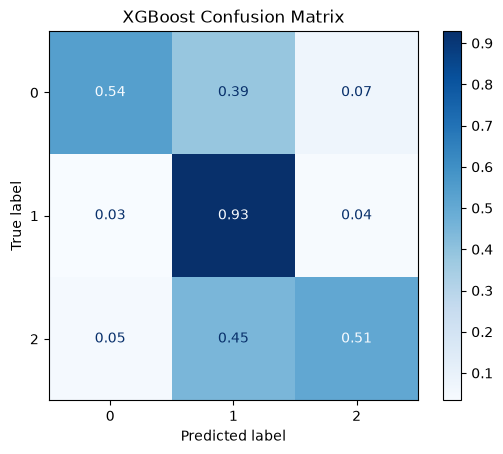

In [14]:
label_encoder=joblib.load("../outputs/encoders/label_encoder.pkl")
class_ids=np.arange(len(label_encoder.classes_))
cm=confusion_matrix(y_test, y_pred, labels=class_ids, normalize="true")
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_ids)
disp.plot(cmap="Blues", values_format=".2f")
plt.title("XGBoost Confusion Matrix")
plt.show()

#### Register model with MlflowClient()

In [15]:


# pre-production model
client=MlflowClient()
model_name="xgboost_financial_sentiment"

# register model
registered_model_xgb=mlflow.register_model(
    model_uri=model_info.model_uri,
    name=model_name
)

# first assign candidate
client.set_registered_model_alias(
    name=model_name,
    alias="candidate",
    version=registered_model_xgb.version
)

print(f"Version {registered_model_xgb.version} registered as candidate")

2026/09/08 16:26:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/08 16:26:25 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Version 1 registered as candidate


Successfully registered model 'xgboost_financial_sentiment'.
Created version '1' of model 'xgboost_financial_sentiment'.


In [16]:
client.set_registered_model_alias(
    name=model_name,
    alias="champion",
    version=registered_model_xgb.version
)

print("Candidate promoted to champion.")

Candidate promoted to champion.


#### delete candidate model

In [17]:
client.delete_registered_model_alias(
    name=model_name,
    alias="candidate"
)

#### Load model from Model Registry alias

In [18]:
loaded_xgb_model=mlflow.xgboost.load_model(
    f"models:/{model_name}@champion"
)
print("Champion XGBoost model is successfully loaded")

Champion XGBoost model is successfully loaded
